<a href="https://colab.research.google.com/github/attabeezy/crop-guard/blob/main/notebooks/01_data_setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CropGuard — CCMT data setup and inspection

This notebook downloads the public CCMT Ghana crop pest and disease dataset, locates image folders, reports counts, and displays random examples. It does **not** train a model or upload dataset files to GitHub.

Authoritative source: [Mendeley Data, DOI 10.17632/bwh3zbpkpv.1](https://data.mendeley.com/datasets/bwh3zbpkpv/1), licensed CC BY 4.0. We will use the original/raw images, not the pre-augmented set.

## 1. Install the downloader

Kaggle hosts a convenient mirror of the Mendeley dataset. `kagglehub` downloads public datasets into Colab's temporary storage.

In [1]:
%pip install -q kagglehub

## 2. Download CCMT

If Kaggle asks for authentication, use Colab's **Secrets** panel to add `KAGGLE_USERNAME` and `KAGGLE_KEY`, then rerun this cell.

In [2]:
from pathlib import Path
import kagglehub

DATASET_HANDLE = "nirmalsankalana/crop-pest-and-disease-detection"
dataset_root = Path(kagglehub.dataset_download(DATASET_HANDLE))
print(f"Dataset downloaded to: {dataset_root}")

100%|██████████| 1.25G/1.25G [01:00<00:00, 22.2MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/nirmalsankalana/crop-pest-and-disease-detection/versions/1


## 3. Inspect the archive structure

In [3]:
print("Top-level entries:")
for path in sorted(dataset_root.iterdir()):
    print("-", path.name)

Top-level entries:
- Cashew anthracnose
- Cashew gumosis
- Cashew healthy
- Cashew leaf miner
- Cashew red rust
- Cassava bacterial blight
- Cassava brown spot
- Cassava green mite
- Cassava healthy
- Cassava mosaic
- Maize fall armyworm
- Maize grasshoper
- Maize healthy
- Maize leaf beetle
- Maize leaf blight
- Maize leaf spot
- Maize streak virus
- Tomato healthy
- Tomato leaf blight
- Tomato leaf curl
- Tomato septoria leaf spot
- Tomato verticulium wilt


In [4]:
from collections import Counter

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}
images = [
    path for path in dataset_root.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
]

folder_counts = Counter(str(path.parent.relative_to(dataset_root)) for path in images)
print(f"Total image files found: {len(images):,}\n")
for folder, count in sorted(folder_counts.items()):
    print(f"{count:7,}  {folder}")

Total image files found: 25,220

  1,729  Cashew anthracnose
    392  Cashew gumosis
  1,368  Cashew healthy
  1,378  Cashew leaf miner
  1,682  Cashew red rust
  2,614  Cassava bacterial blight
  1,481  Cassava brown spot
  1,015  Cassava green mite
  1,193  Cassava healthy
  1,205  Cassava mosaic
    285  Maize fall armyworm
    673  Maize grasshoper
    208  Maize healthy
    948  Maize leaf beetle
  1,006  Maize leaf blight
  1,259  Maize leaf spot
    979  Maize streak virus
    470  Tomato healthy
  1,301  Tomato leaf blight
    518  Tomato leaf curl
  2,743  Tomato septoria leaf spot
    773  Tomato verticulium wilt


The official raw-image totals are approximately 6,549 cashew, 7,508 cassava, 5,389 maize, and 5,435 tomato images. A total near 102,976 indicates the augmented data and must not be used for our honest split.

## 4. View random examples

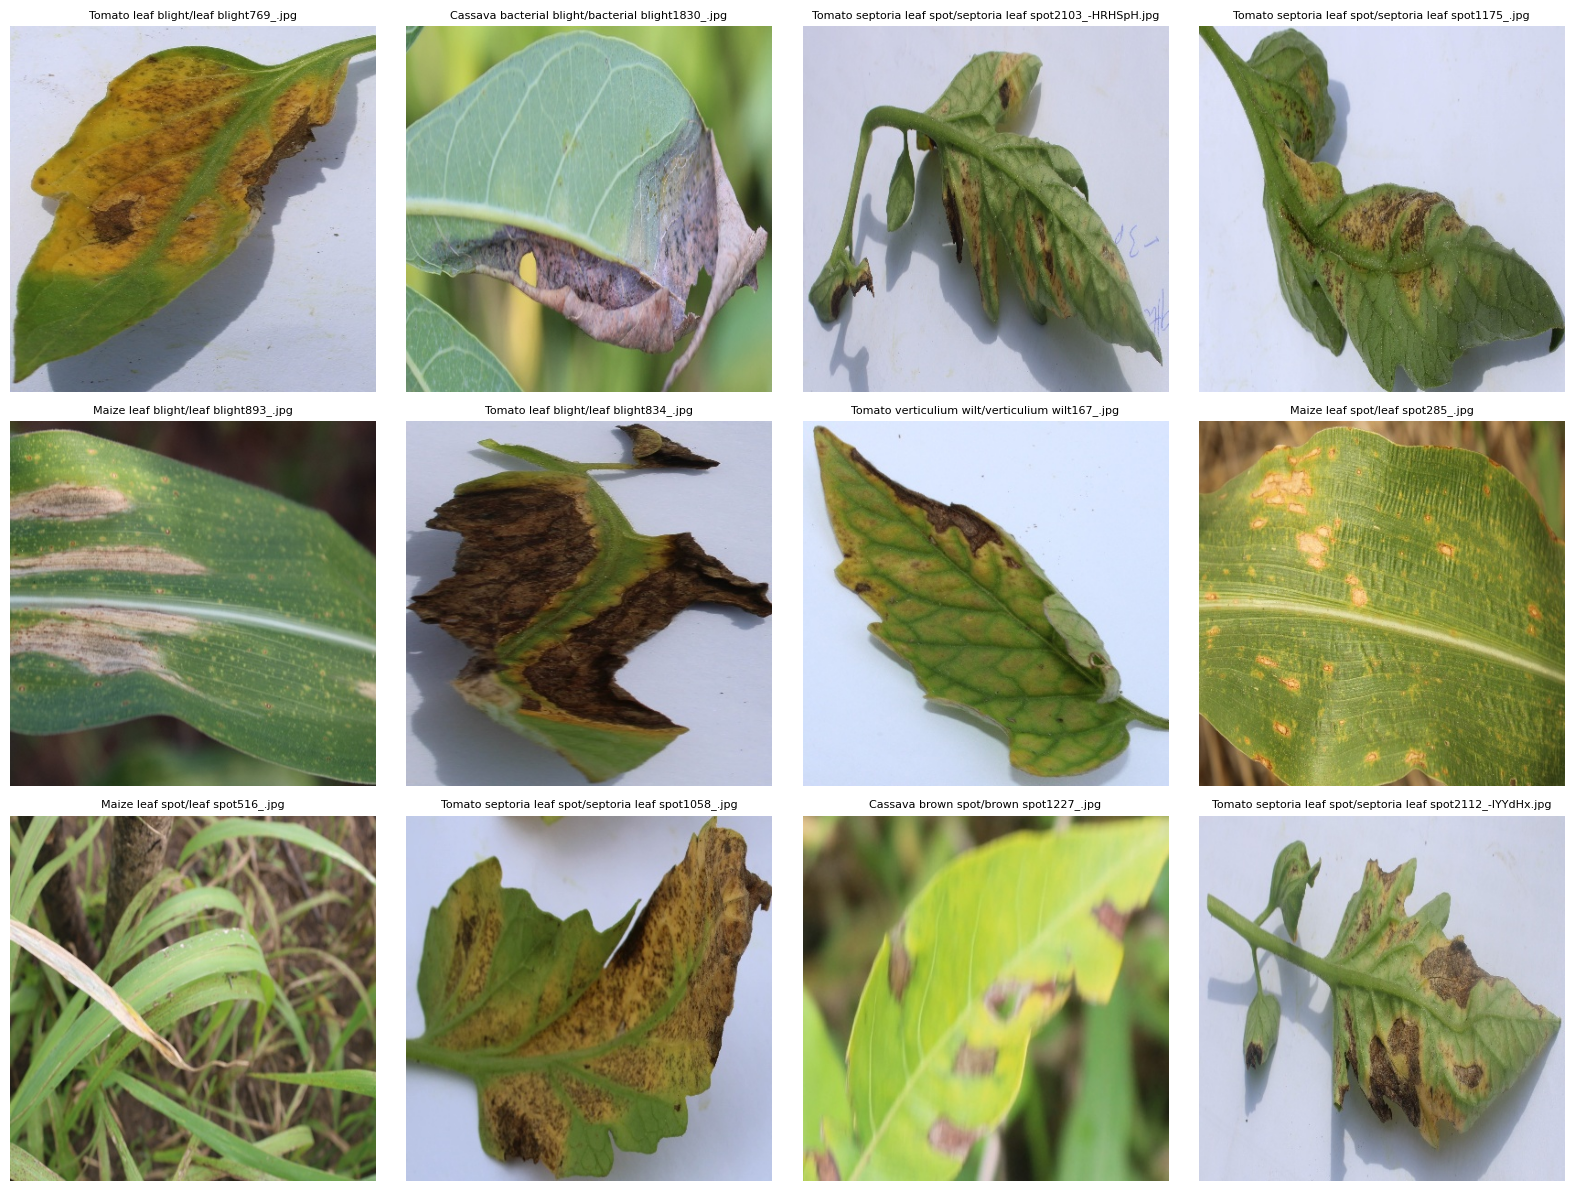

In [5]:
import random
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

random.seed(2026)
samples = random.sample(images, min(12, len(images)))
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for axis, path in zip(axes.flat, samples):
    with Image.open(path) as source:
        axis.imshow(ImageOps.exif_transpose(source).convert("RGB"))
    axis.set_title(str(path.relative_to(dataset_root)), fontsize=8)
    axis.axis("off")

for axis in axes.flat[len(samples):]:
    axis.axis("off")

plt.tight_layout()

## 5. Check the expected classes

CropGuard's locked scope is cashew, cassava, and maize. The expected 17 classes are listed below. Folder spelling may differ, so inspect the count table before reorganizing anything.

In [6]:
expected_classes = {
    "cashew": ["anthracnose", "gummosis", "healthy", "leaf miner", "red rust"],
    "cassava": ["bacterial blight", "brown spot", "green mite", "healthy", "mosaic"],
    "maize": ["fall armyworm", "grasshopper", "healthy", "leaf beetle", "leaf blight", "leaf spot", "streak virus"],
}

for crop, classes in expected_classes.items():
    print(f"{crop.title()} ({len(classes)} classes): {', '.join(classes)}")

Cashew (5 classes): anthracnose, gummosis, healthy, leaf miner, red rust
Cassava (5 classes): bacterial blight, brown spot, green mite, healthy, mosaic
Maize (7 classes): fall armyworm, grasshopper, healthy, leaf beetle, leaf blight, leaf spot, streak virus


## Next step

Run all cells, then save or share the folder-count output. The preparation script will be adjusted to the archive's verified raw-folder layout before creating train, validation, and test manifests.